# Clustering với k-Means

In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định

**Giả sử có 3 tập**
1. Set 1: 50 điểm
1. Set 2: 75 điểm
1. Set 3: 100 điểm

In [2]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

**=== Hiển thị 3 tập để kiểm tra ===**

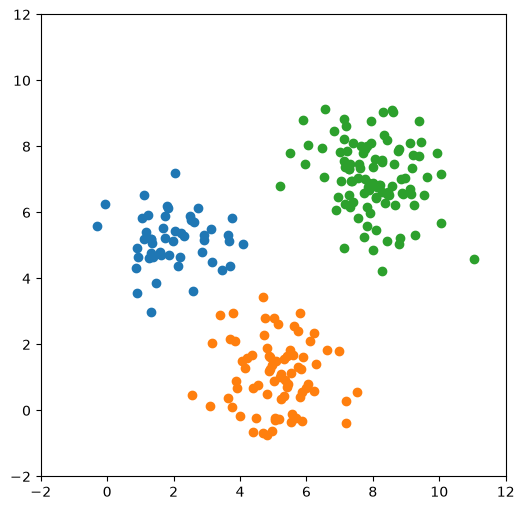

In [3]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập chưa được clustered

In [4]:
dat1 = np.stack([x1, y1]).T

In [5]:
dat2 = np.stack([x2,y2]).T
dat3 = np.stack([x3,y3]).T

**=== Tập dữ liệu giả định có 225 dòng, 2 cột (x,y) ===**

In [6]:
dat = np.vstack([dat1, dat2, dat3])
print(dat.shape)

(225, 2)


### Sắp ngẫu nhiên các dòng

In [7]:
np.random.shuffle(dat)

### Kiểm tra lại với biểu đồ scatter

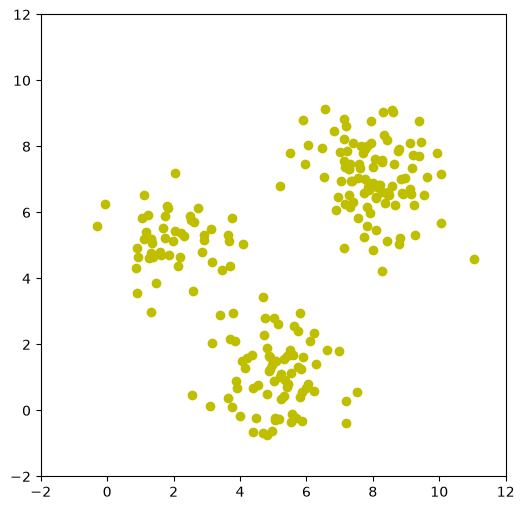

In [8]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.show()

## 2. Thực hiện phân cụm

### 2.1. Giả sử K=3 và tìm 3 điểm ban đầu ngẫu nhiên

In [9]:
K = 3

In [10]:
indices = np.random.choice(len(dat), K, replace=False)
centroids = dat[indices].copy()
print(centroids)

[[4.225 1.602]
 [5.618 2.559]
 [7.813 5.573]]


**Gán các trung tâm cho 3 điểm này**

In [11]:
centroids = np.stack(centroids)

**=== Vẽ K điểm centroids ban đầu lên biểu đồ ===**

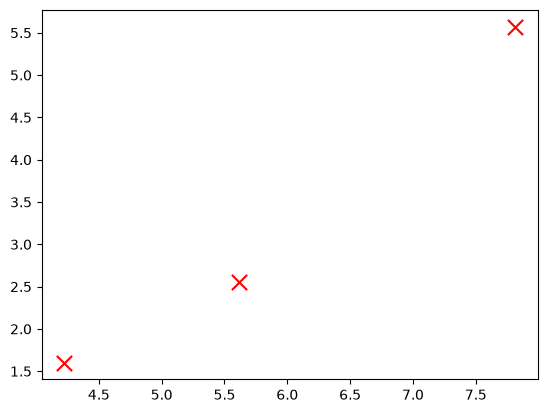

In [12]:
plt.scatter(centroids[:, 0], centroids[:, 1], color='r', marker='x', s=120)

### 2.2. Tiến hành gom cụm lần 1

**=== Khởi tạo K danh sách rỗng (để chứa các điểm của mỗi cluster) ===**

In [13]:
cList = [[] for _ in range(K)]

**=== Với mỗi sample, tìm xem nó gần điểm centroid nào nhất ===**

In [14]:
for sample in dat:
    distances = np.sum((sample - centroids) ** 2, axis=1)
    nearest = np.argmin(distances)
    cList[nearest].append(sample)

In [15]:
# Thử kiểm tra lại mỗi list
for i in range(K): print(len(cList[i]))

86
39
100


**=== Thử lấy cluster đầu tiên ra và đánh giá ===**

In [16]:
np.stack(cList[0]).shape

(86, 2)

In [17]:
new_centroid_0 = np.stack(cList[0]).mean(axis=0)
print(new_centroid_0)

[3.351 2.555]


**=== Tính lại các điểm centroids ===**

In [18]:
centroids = np.stack([np.stack(points).mean(axis=0) for points in cList])

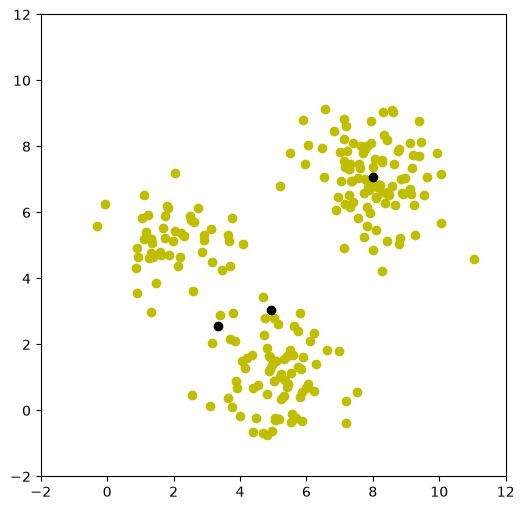

In [19]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.3. Tiến hành gom cụm lần 2

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [20]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

# Tính giá trị của các centroids mới
centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[2.628 3.533]
 [5.438 1.63 ]
 [8.016 7.064]]


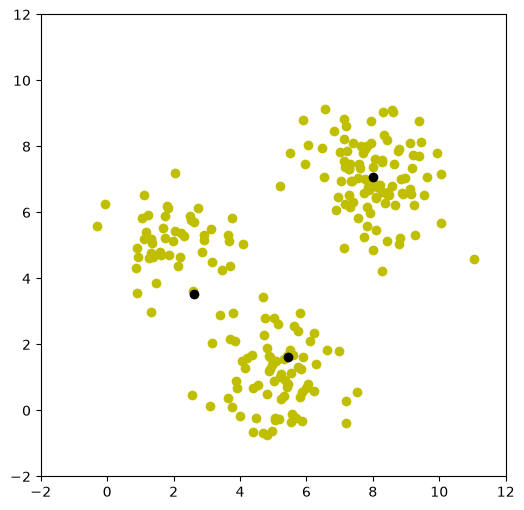

In [21]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.4. Tiến hành gom cụm lần 3

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [22]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[2.096 4.87 ]
 [5.214 1.014]
 [8.016 7.064]]


**==> Nhận xét: các giá trị trung tâm gần như ít thay đổi**

In [23]:
# Lấy ra các cluster



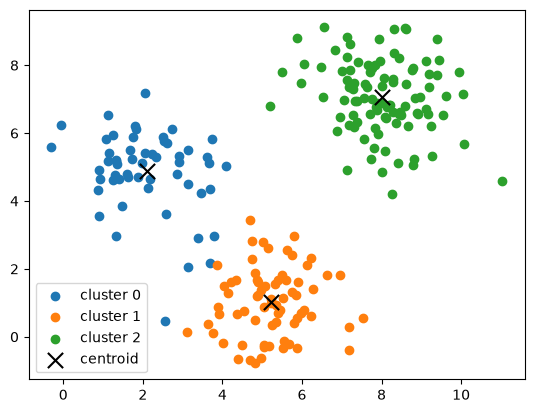

In [24]:
for i in range(K):
    points = np.stack(cList[i])
    plt.scatter(points[:, 0], points[:, 1], label=f'cluster {i}')
plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='x', s=120, label='centroid')
plt.legend()